In [25]:
import pandas as pd
import numpy as np



import sys
sys.path.append('..')

# Loading Data

In [26]:
df_raw = pd.read_parquet(f"../data_in_processing/data_top5std.parquet")

df_raw = df_raw.set_index(["image_T"] + [f"track_id_t{i}" for i in range(5+1)])

df_raw

ERK_diff_t0  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272           -1.000000   
        1264        1316        1300        1264        1300        1272           -1.000000   
        1419        1316        1300        1264        1300        1272           -1.000000   
        1300        1316        1300        1264        1300        1272           -1.000000   
        1019        1316        1300        1264        1300        1272           -1.000000   
...                                                                                      ...   
251     1114        72          1053        1004        1052        1117            0.006720   
        283         72          1053        1004        1052        1117            0.006720   
        1114        283         72          2475        1052        1117           -0.006981   
                    72          2475        1004        399         1117            0.006720   
                                1053        1004        399         1117            0.006720   

                                                                                 ERK_diff_t1  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272            0.786236   
        1264        1316        1300        1264        1300        1272            0.786236   
        1419        1316        1300        1264        1300        1272            0.786236   
        1300        1316        1300        1264        1300        1272            0.786236   
        1019        1316        1300        1264        1300        1272            0.786236   
...                                                                                      ...   
251     1114        72          1053        1004        1052        1117            0.026285   
        283         72          1053        1004        1052        1117            0.026285   
        1114        283         72          2475        1052        1117           -0.006943   
                    72          2475        1004        399         1117            0.017854   
                                1053        1004        399         1117            0.026285   

                                                                                 ERK_diff_t2  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272           -0.004751   
        1264        1316        1300        1264        1300        1272           -0.004751   
        1419        1316        1300        1264        1300        1272           -0.004751   
        1300        1316        1300        1264        1300        1272           -0.004751   
        1019        1316        1300        1264        1300        1272           -0.004751   
...                                                                                      ...   
251     1114        72          1053        1004        1052        1117           -0.027770   
        283         72          1053        1004        1052        1117           -0.027770   
        1114        283         72          2475        1052        1117            0.011757   
                    72          2475        1004        399         1117           -0.027770   
                                1053        1004        399         1117           -0.027770   

                                                                                 ERK_diff_t3  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272           -0.703872   
        1264        1316        1300        12

# Selecting every 2th row to speedup tuning HDBSCAN

In [27]:
df = df_raw.iloc[::2]

df

ERK_diff_t0  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272           -1.000000   
        1419        1316        1300        1264        1300        1272           -1.000000   
        1019        1316        1300        1264        1300        1272           -1.000000   
        1419        1316        1300        762         1300        1272           -1.000000   
        762         1316        1300        762         1300        1272           -1.000000   
...                                                                                      ...   
251     72          2475        1004        399         1052        1117            0.007409   
        283         72          2475        1004        1052        1117            0.006720   
        1114        72          1053        1004        1052        1117            0.006720   
                    283         72          2475        1052        1117           -0.006981   
                    72          1053        1004        399         1117            0.006720   

                                                                                 ERK_diff_t1  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272            0.786236   
        1419        1316        1300        1264        1300        1272            0.786236   
        1019        1316        1300        1264        1300        1272            0.786236   
        1419        1316        1300        762         1300        1272            0.786236   
        762         1316        1300        762         1300        1272            0.786236   
...                                                                                      ...   
251     72          2475        1004        399         1052        1117           -0.022419   
        283         72          2475        1004        1052        1117            0.017854   
        1114        72          1053        1004        1052        1117            0.026285   
                    283         72          2475        1052        1117           -0.006943   
                    72          1053        1004        399         1117            0.026285   

                                                                                 ERK_diff_t2  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272           -0.004751   
        1419        1316        1300        1264        1300        1272           -0.004751   
        1019        1316        1300        1264        1300        1272           -0.004751   
        1419        1316        1300        762         1300        1272           -0.011782   
        762         1316        1300        762         1300        1272           -0.011782   
...                                                                                      ...   
251     72          2475        1004        399         1052        1117           -0.003896   
        283         72          2475        1004        1052        1117           -0.027770   
        1114        72          1053        1004        1052        1117           -0.027770   
                    283         72          2475        1052        1117            0.011757   
                    72          1053        1004        399         1117           -0.027770   

                                                                                 ERK_diff_t3  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272           -0.703872   
        1419        1316        1300        12

In [28]:
df.describe()

,ERK_diff_t0,ERK_diff_t1,ERK_diff_t2,ERK_diff_t3,ERK_diff_t4
count,869003.000000,869003.000000,869003.000000,869003.000000,869003.000000
mean,0.001424,0.013044,0.027691,0.040721,0.056860
std,0.115428,0.167070,0.208136,0.240344,0.294681
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,-0.036417,-0.047399,-0.056433,-0.066718,-0.128094
50%,-0.005691,-0.005476,-0.003058,0.000429,0.002195
75%,0.018730,0.033692,0.077699,0.162468,0.291966
max,1.000000,1.000000,1.000000,1.000000,1.000000


# Plotting Data Distributions

In [29]:
import matplotlib.pyplot as plt
from matplotlib.axes import Axes

In [30]:
def plot_two_columns(ax: Axes, col1_name: str, col2_name: str, col1_data: np.ndarray, col2_data: np.ndarray, alpha: float = 0.01) -> None:
    ax.scatter(col1_data, col2_data, marker = ".", alpha=alpha)
    ax.set_xlabel(col1_name)
    ax.set_ylabel(col2_name)
    ax.set_title(f"{col1_name[-1]} vs {col2_name[-1]}")

In [31]:
def plot_all_columns(df: pd.DataFrame, save_path: str|None = None) -> None:

    fig, axs = plt.subplots(len(df.columns), len(df.columns), figsize=(6*len(df.columns), 6*len(df.columns)))

    for i, col1 in enumerate(df.columns):
        for j, col2 in enumerate(df.columns):
            plot_two_columns(
                ax = axs[i][j],
                col1_name=col1,
                col2_name=col2,
                col1_data=df[col1].to_numpy(),
                col2_data=df[col2].to_numpy(),
                alpha=0.005
            )

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path)

In [32]:
# plot_all_columns(df_raw, save_path=f"../outputs/distributions_of_chains.png")

# Clustering Utilities

In [33]:
from sklearn.cluster import MiniBatchKMeans
import hdbscan

In [34]:
def helper_clustering(df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    compression_kmeans = MiniBatchKMeans(
        n_clusters=100_000,
        batch_size=25_600,
    )

    centroid_assigments = compression_kmeans.fit_predict(df.to_numpy())
    centroids = compression_kmeans.cluster_centers_

    return centroid_assigments, centroids

def cluster_centroids(df: pd.DataFrame) -> np.ndarray:
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=256,
        min_samples=2,
        core_dist_n_jobs=12
    )

    centroid_assigments, centroids = helper_clustering(df)
    centroid_labels = clusterer.fit_predict(centroids)

    return centroid_labels[centroid_assigments]

def cluster_with_pure_hdbscan(df: pd.DataFrame) -> tuple[np.ndarray, hdbscan.HDBSCAN]:
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=256,
        min_samples=64,
        core_dist_n_jobs=12,
        cluster_selection_epsilon=0,
    )

    return clusterer.fit_predict(df.to_numpy()), clusterer

# Run Clustering

In [35]:
clus_id: int = 4

In [36]:
df["label"], clusterer = cluster_with_pure_hdbscan(df)

In [37]:
df.head(20)

ERK_diff_t0  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272                -1.0   
        1419        1316        1300        1264        1300        1272                -1.0   
        1019        1316        1300        1264        1300        1272                -1.0   
        1419        1316        1300        762         1300        1272                -1.0   
        762         1316        1300        762         1300        1272                -1.0   
        1419        1316        1300        975         1300        1272                -1.0   
        1300        1316        1300        975         1300        1272                -1.0   
        762         1316        1300        975         1300        1272                -1.0   
        1419        1316        1300        1272        1300        1272                -1.0   
        1300        1316        1300        1272        1300        1272                -1.0   
        1419        1316        1300        1264        1300        975                 -1.0   
        1264        1316        1300        1264        1300        975                 -1.0   
        762         1316        1300        1264        1300        975                 -1.0   
        975         1300        1316        1264        1300        1272                -1.0   
        1272        1300        1316        762         1300        1272                -1.0   
        1316        1300        1316        762         1300        1272                -1.0   
        1272        1300        1316        1264        1300        975                 -1.0   
                                            762         1300        975                 -1.0   
        1316        1300        1316        762         1300        975                 -1.0   
                                            1264        1300        762                 -1.0   

                                                                                 ERK_diff_t1  \
image_T track_id_t0 track_id_t1 track_id_t2 track_id_t3 track_id_t4 track_id_t5                
0       762         1316        1300        1264        1300        1272            0.786236   
        1419        1316        1300        1264        1300        1272            0.786236   
        1019        1316        1300        1264        1300        1272            0.786236   
        1419        1316        1300        762         1300        1272            0.786236   
        762         1316        1300        762         1300        1272            0.786236   
        1419        1316        1300        975         1300        1272            0.786236   
        1300        1316        1300        975         1300        1272            0.786236   
        762         1316        1300        975         1300        1272            0.786236   
        1419        1316        1300        1272        1300        1272            0.786236   
        1300        1316        1300        1272        1300        1272            0.786236   
        1419        1316        1300        1264        1300        975             0.786236   
        1264        1316        1300        1264        1300        975             0.786236   
        762         1316        1300        1264        1300        975             0.786236   
        975         1300        1316        1264        1300        1272            0.621627   
        1272        1300        1316        762         1300        1272            0.621627   
        1316        1300        1316        762         1300        1272            0.621627   
        1272        1300        1316        1264        1300        975             0.621627   
                                            762         1300        975             0.621627   
        1316        1300        1316        762 

# Cluster Statistics

In [38]:
from scripts.Scoring_clusters import clustering_coverage_stats, run_scoring

In [39]:
df["label"].value_counts()

label
-1     658024
 26     79670
 24     51654
 18     26409
 23     18063
 20     11189
 19      6938
 16      3830
 22      3736
 7       1408
 10      1341
 15      1023
 0        552
 27       406
 8        385
 21       356
 11       353
 25       344
 17       344
 4        336
 3        330
 9        330
 6        328
 5        289
 12       281
 14       277
 2        277
 13       268
 1        262
Name: count, dtype: int64

In [40]:
len(df["label"].unique())

29

In [41]:
clustering_coverage_stats(df)


    Nodes with Labels:				210979
    Nodes without Labels:			658024
    Nodes ratio [with label / all]:		210979 / 869003
    Nodes ratio [with label / all][%]:		24.28%
    Noise [without label / all][%]:		75.72%
    


In [42]:
_ = run_scoring(df)

Davies-Bouldin Score:                   0.665
Calinski-Harabasz Score:                68366.996


# Viewing Stats about Labels

In [43]:
def plot_hist_all(df: pd.DataFrame, save_path: str) -> None:

    selected_columns = [col for col in df.columns if col not in {"label"}]

    fig, axs = plt.subplots(len(selected_columns), figsize = (10, 3 * len(df.columns)))

    for i, col in enumerate(selected_columns):
        
        axs[i].hist(df[col], rwidth = 0.8, bins = 1000, alpha = 1)
        axs[i].set_title(col)
        axs[i].set_xlabel(f"ERK ratio value")
        axs[i].set_ylabel(f"Count")



    fig.tight_layout()

    fig.savefig(save_path)

In [ ]:
def plot_hist_labels_selected(df: pd.DataFrame, labels_selected: list[int], save_path: str|None = None) -> None:
    selected_columns = [col for col in df.columns if col not in {"label"}]

    fig, axs = plt.subplots(len(selected_columns), figsize = (10, 3 * len(df.columns)))

    for i, col in enumerate(selected_columns):
        
        for lab_idx in labels_selected:
            axs[i].hist(df[df["label"] == lab_idx][col], rwidth = 0.8, bins = 100, alpha = 0.5, label = f"lab = {lab_idx}")
        axs[i].set_title(col)
        axs[i].legend(fontsize=10)
        axs[i].set_xlabel(f"ERK ratio value")
        axs[i].set_ylabel(f"Count")



    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path)

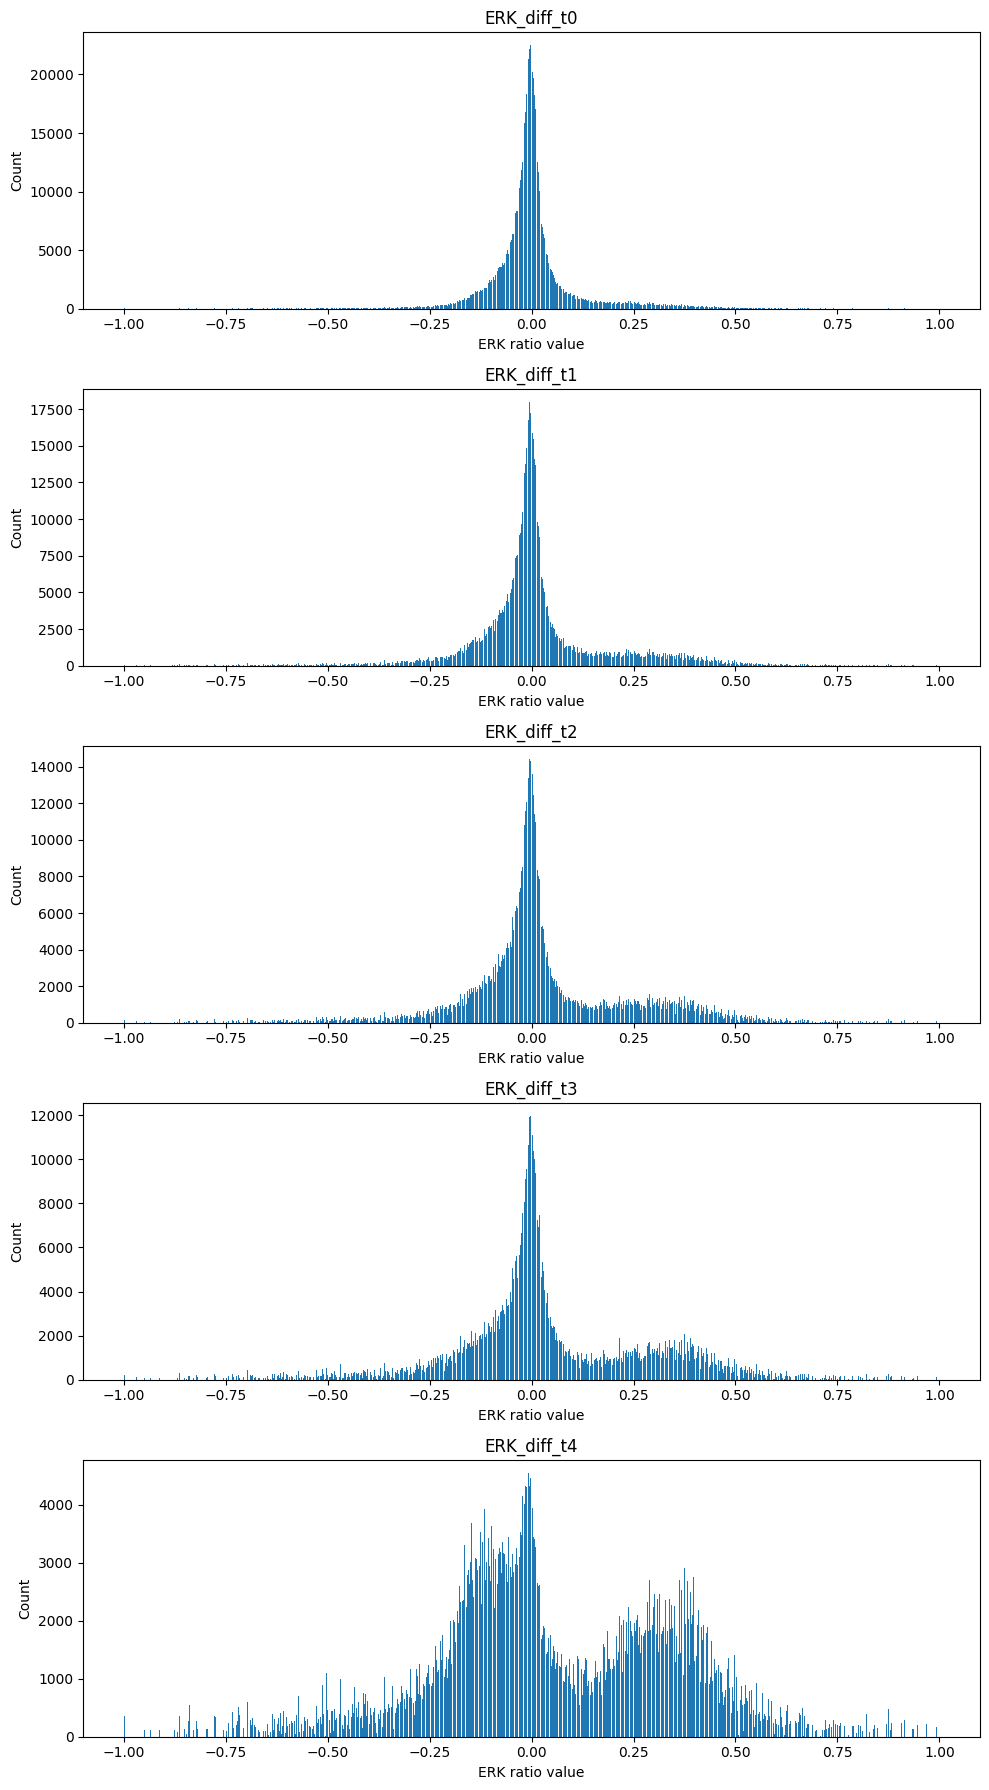

In [45]:
plot_hist_all(df, f"../outputs/all_chains_histograms.png")

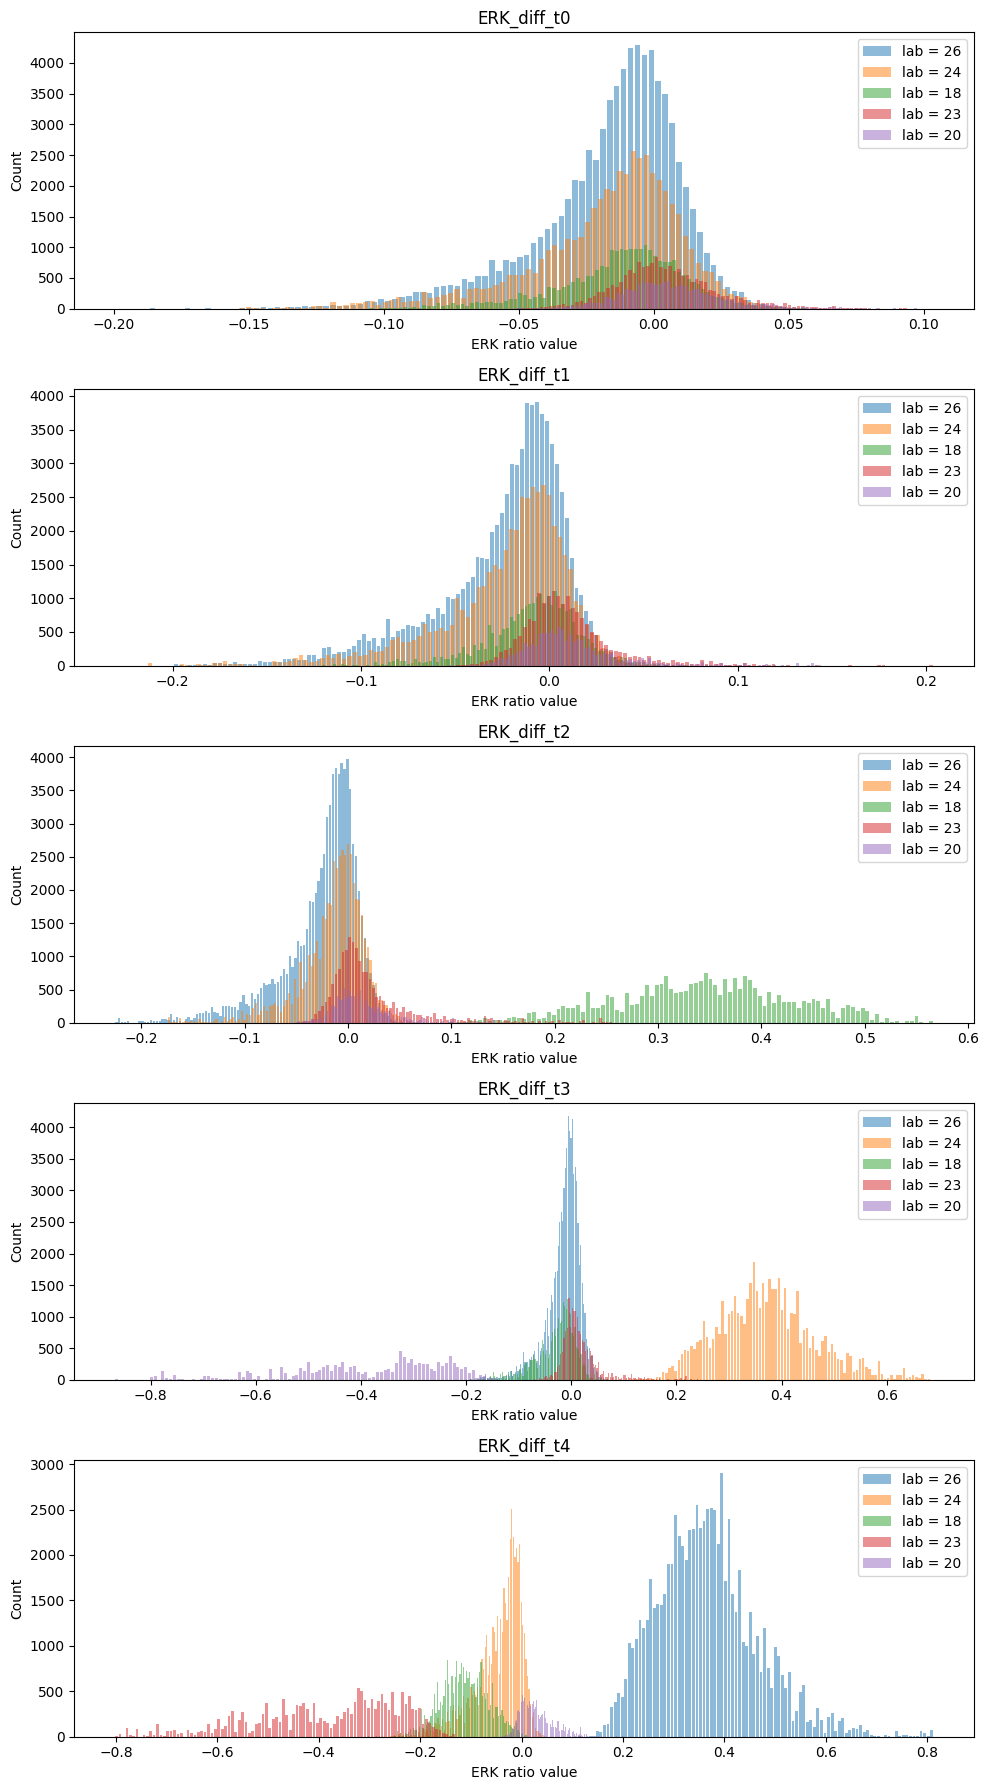

In [56]:
plot_hist_labels_selected(
    df,
    [lab for lab, lab_count in df["label"].value_counts().to_dict().items() if lab != -1 and lab_count>10_000],
    f"../outputs/labels_chains_histograms.png")

# Saving Labels & Params

In [47]:
import pickle

In [49]:
df.drop(columns=[col for col in df.columns if col not in {"label"}]).to_csv(f"../data_in_processing/cluster_outputs/labels_{clus_id}.csv")

with open(f"../data_in_processing/cluster_outputs/params_{clus_id}.pickle", "wb") as params_f:
    pickle.dump(clusterer.get_params(), params_f)

with open(f"../data_in_processing/cluster_outputs/clusterer_{clus_id}.pickle", "wb") as params_f:
    pickle.dump(clusterer, params_f)

# Searching For Labels

In [53]:
def plot_hist_labels_selected(df: pd.DataFrame, labels_selected: list[int], save_path: str|None = None) -> None:
    selected_columns = [col for col in df.columns if col not in {"label"}]

    fig, axs = plt.subplots(len(selected_columns), figsize = (10, 3 * len(df.columns)))

    for i, col in enumerate(selected_columns):
        
        for lab_idx in labels_selected:
            axs[i].hist(df[df["label"] == lab_idx][col], rwidth = 0.8, bins = 100, alpha = 0.5, label = f"lab = {lab_idx}")
        axs[i].set_title(col)
        axs[i].legend(fontsize=10)
        axs[i].set_xlabel(f"ERK ratio value")
        axs[i].set_ylabel(f"Count")



    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path)

In [54]:
df["label"].value_counts()

label
-1     658024
 26     79670
 24     51654
 18     26409
 23     18063
 20     11189
 19      6938
 16      3830
 22      3736
 7       1408
 10      1341
 15      1023
 0        552
 27       406
 8        385
 21       356
 11       353
 25       344
 17       344
 4        336
 3        330
 9        330
 6        328
 5        289
 12       281
 14       277
 2        277
 13       268
 1        262
Name: count, dtype: int64